# Random ROI selection-Automatic

The objective of this code is to extract tiles in the specified ROI from ground_truth patch using different masks

##### Input and output folder structure

##### Input to the program

In [18]:
import os, re, glob, shutil, csv
import numpy as np
import openslide
from PIL import Image
from tqdm import tqdm

# =========================
# Edit these inputs
# =========================
# Extracted patche and tiles location for each dataset
PATCH_ROOT = "/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Original_selected_2048_patch"

# Output location
OUTPUT_ROOT = "/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Filtered_tiles_4methods_new2"

# WSI location
WSI_SEARCH_ROOTS = [
    "/data_64T_2/Dataset/TCGA_BLCA/images/Tumor_DX1",
    "/data_64T_2/Dataset/TCGA_BRCA/images/Tumor_DX1",
    "/data_64T_2/Dataset/TCGA_STAD/images/Tumor_DX1",
    "/data_64T_2/Dataset/TCGA_LUAD/images/Tumor_DX1",
    "/data_64T_2/Dataset/TCGA_COAD/images/Tumor_DX1",
    "/data_64T_2/Dataset/TCGA_READ/images/Tumor_DX1",
    # add more cohorts as needed
]

# Which method to use to extract the patches and tiles
Methods = ["CLAM", "TRIDENT", "HISTOLAB", "MUFASA"]
# Based on the above set mask location
MASK_SEARCH_ROOTS = {
    "CLAM":    ["/data_64T_2/Dataset/TCGA_BLCA/masks/CLAM", 
                "/data_64T_2/Dataset/TCGA_BRCA/masks/CLAM", 
                "/data_64T_2/Dataset/TCGA_COAD/masks/CLAM", 
                "/data_64T_2/Dataset/TCGA_READ/masks/CLAM", 
                "/data_64T_2/Dataset/TCGA_LUAD/masks/CLAM", 
                "/data_64T_2/Dataset/TCGA_STAD/masks/CLAM"],
    "TRIDENT": ["/data_64T_2/Dataset/TCGA_BLCA/masks/TRIDENT", 
                "/data_64T_2/Dataset/TCGA_BRCA/masks/TRIDENT", 
                "/data_64T_2/Dataset/TCGA_COAD/masks/TRIDENT", 
                "/data_64T_2/Dataset/TCGA_READ/masks/TRIDENT",
                "/data_64T_2/Dataset/TCGA_LUAD/masks/TRIDENT",
                "/data_64T_2/Dataset/TCGA_STAD/masks/TRIDENT"],
    "HISTOLAB":["/data_64T_2/Dataset/TCGA_BLCA/masks/HISTOLAB",
                "/data_64T_2/Dataset/TCGA_BRCA/masks/HISTOLAB",
                "/data_64T_2/Dataset/TCGA_COAD/masks/HISTOLAB", 
                "/data_64T_2/Dataset/TCGA_READ/masks/HISTOLAB",
                "/data_64T_2/Dataset/TCGA_LUAD/masks/HISTOLAB",
                "/data_64T_2/Dataset/TCGA_STAD/masks/HISTOLAB"],
    "MUFASA":  ["/data_64T_2/Dataset/TCGA_BLCA/masks/MUFASA",  # Informative1_mask (change the mask name to WSI name)
                "/data_64T_2/Dataset/TCGA_BRCA/masks/MUFASA",  # Informative1_mask (change the mask name to WSI name)
                "/data_64T_2/Dataset/TCGA_COAD/masks/MUFASA",  # Informative1_mask (change the mask name to WSI name)
                "/data_64T_2/Dataset/TCGA_READ/masks/MUFASA",  # Informative1_mask (change the mask name to WSI name)
                "/data_64T_2/Dataset/TCGA_LUAD/masks/MUFASA",  # Informative1_mask (change the mask name to WSI name)
                "/data_64T_2/Dataset/TCGA_STAD/masks/MUFASA"],  # Informative1_mask (change the mask name to WSI name)
}

# Minimum tissue area to cover
MIN_FRAC_BY_METHOD = {"CLAM": 0.25, "TRIDENT": 0.25, "HISTOLAB": 0.25, "MUFASA": 0.75}

BG_THRESH = 15
PATCH_SIZE = 2048
TILE_SIZE = 256
MASK_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff")

##### code

In [19]:
# =========================
# Helpers
# =========================
def safe_mkdir(p: str):
    os.makedirs(p, exist_ok=True)

def list_slides_with_qupath_tiles(patch_root: str):
    slides = []
    for d in os.listdir(patch_root):
        slide_dir = os.path.join(patch_root, d)
        if not os.path.isdir(slide_dir):
            continue
        if os.path.isdir(os.path.join(slide_dir, "tiles", "patch01")) and os.path.isdir(os.path.join(slide_dir, "tiles", "patch02")):
            slides.append(d)
    return sorted(slides)

def already_done(out_base: str):
    """
    Consider a (slide, method) DONE if:
      - mask_patches/patch01_mask.png and patch02_mask.png exist
      - patch01 and patch02 output folders exist and are non-empty
    """
    mp = os.path.join(out_base, "mask_patches")
    p1 = os.path.join(out_base, "patch01")
    p2 = os.path.join(out_base, "patch02")
    ok_masks = os.path.exists(os.path.join(mp, "patch01_mask.png")) and os.path.exists(os.path.join(mp, "patch02_mask.png"))
    ok_tiles = os.path.isdir(p1) and os.path.isdir(p2) and (len(os.listdir(p1)) > 0) and (len(os.listdir(p2)) > 0)
    return ok_masks and ok_tiles

def build_wsi_map(search_roots):
    wsi_map = {}
    exts = (".svs", ".tif", ".tiff", ".ndpi", ".scn", ".mrxs")
    for root in search_roots:
        if not os.path.exists(root):
            print(f"[BAD ROOT] {root}")
            continue
        for p in glob.glob(os.path.join(root, "**", "*"), recursive=True):
            if os.path.isfile(p) and p.lower().endswith(exts):
                name = os.path.splitext(os.path.basename(p))[0]
                wsi_map[name] = p
    return wsi_map

def find_mask_file_for_method(slide_name: str, method: str):
    """
    STRICT MUFASA behavior:
      - only accept: {slide_name}_Informative_set1_masked_overlay.(png|jpg|tif|tiff)
      - NO broad fallback search for MUFASA
    """
    roots = MASK_SEARCH_ROOTS[method]

    if method == "CLAM":
        patterns = [
            f"{slide_name}.jpg", f"{slide_name}.jpeg", f"{slide_name}.png", f"{slide_name}.tif", f"{slide_name}.tiff"
        ]
    elif method in ("HISTOLAB", "TRIDENT"):
        patterns = [
            f"{slide_name}_tissue_overlay.tiff", f"{slide_name}_tissue_overlay.tif",
            f"{slide_name}.tiff", f"{slide_name}.tif", f"{slide_name}.png", f"{slide_name}.jpg"
        ]
    elif method == "MUFASA":
        patterns = [
            f"{slide_name}_Informative_set1_masked_overlay.png",
            f"{slide_name}_Informative_set1_masked_overlay.jpg",
            f"{slide_name}_Informative_set1_masked_overlay.tif",
            f"{slide_name}_Informative_set1_masked_overlay.tiff",
        ]
    else:
        patterns = [f"{slide_name}{ext}" for ext in MASK_EXTS]

    for root in roots:
        slide_dir = os.path.join(root, slide_name)

        # Prefer: masks/MUFASA/<slide_id>/**/<exact_file>
        if os.path.isdir(slide_dir):
            for fname in patterns:
                hits = glob.glob(os.path.join(slide_dir, "**", fname), recursive=True)
                if hits:
                    return sorted(hits)[0]

        # Then: search entire root for exact filename matches only
        for fname in patterns:
            hits = glob.glob(os.path.join(root, "**", fname), recursive=True)
            if hits:
                return sorted(hits)[0]

    # Broad fallback is allowed for non-MUFASA only
    if method != "MUFASA":
        for root in roots:
            hits = []
            for ext in MASK_EXTS:
                hits.extend(glob.glob(os.path.join(root, "**", f"{slide_name}*{ext}"), recursive=True))
            hits = sorted(set(hits))
            if hits:
                return hits[0]

    return None

def load_overlay_resized(mask_path: str, target_wh):
    img = Image.open(mask_path).convert("RGB")
    return img.resize(target_wh, Image.NEAREST)

def overlay_to_tissue_bool(overlay_rgb: Image.Image, bg_thresh: int):
    arr = np.array(overlay_rgb)
    tissue = (arr[...,0] > bg_thresh) | (arr[...,1] > bg_thresh) | (arr[...,2] > bg_thresh)
    return tissue

# Parse x,y from tile filenames: ..._x4096_y256_...
XY_RE = re.compile(r"_x(\d+)_y(\d+)_")
def parse_xy_from_tile_filename(fn: str):
    m = XY_RE.search(fn)
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

# Parse patch coords from patch tif filename:
# ..._patch01_x4096_y0_...
PATCHXY_RE = re.compile(r"_patch(0[12])_x(\d+)_y(\d+)_")
def get_patch_coords_from_patch_tifs(slide_dir: str):
    patch_dir = os.path.join(slide_dir, "patches")
    out = {}
    if not os.path.isdir(patch_dir):
        return out
    for fn in os.listdir(patch_dir):
        if not fn.lower().endswith((".tif", ".tiff")):
            continue
        m = PATCHXY_RE.search(fn)
        if not m:
            continue
        pid = f"patch{m.group(1)}"   # patch01/patch02
        out[pid] = (int(m.group(2)), int(m.group(3)))
    return out

def tissue_fraction(tissue_bool: np.ndarray, x: int, y: int, tile_sz: int):
    region = tissue_bool[y:y+tile_sz, x:x+tile_sz]
    if region.size == 0:
        return 0.0
    return float(region.mean())

##### Main function

In [ ]:
# =========================
# MAIN
# =========================
slides = list_slides_with_qupath_tiles(PATCH_ROOT)
print(f"Slides found in QuPath patch root: {len(slides)}")

wsi_map = build_wsi_map(WSI_SEARCH_ROOTS)
print(f"WSIs indexed from search roots: {len(wsi_map)}")

safe_mkdir(OUTPUT_ROOT)
summary_path = os.path.join(OUTPUT_ROOT, "summary.csv")

summary_rows = []
missing_wsi = []
missing_masks = {m: [] for m in MASK_SEARCH_ROOTS.keys()}

for slide_name in tqdm(slides, desc="Slides", unit="slide"):
    if slide_name not in wsi_map:
        missing_wsi.append(slide_name)
        continue

    wsi_path = wsi_map[slide_name]
    slide = openslide.OpenSlide(wsi_path)
    W, H = slide.level_dimensions[0]  # level-0
    target_wh = (W, H)

    slide_dir = os.path.join(PATCH_ROOT, slide_name)

    # Patch coordinate source (best): patch tif filenames
    patch_xy = get_patch_coords_from_patch_tifs(slide_dir)
    if "patch01" not in patch_xy or "patch02" not in patch_xy:
        # fallback: infer from tile filenames min x,y
        patch_xy = {}
        for pid in ("patch01", "patch02"):
            tdir = os.path.join(slide_dir, "tiles", pid)
            xs, ys = [], []
            if not os.path.isdir(tdir):
                continue
            for fn in os.listdir(tdir):
                if not fn.lower().endswith(".png"):
                    continue
                xy = parse_xy_from_tile_filename(fn)
                if xy:
                    xs.append(xy[0]); ys.append(xy[1])
            if xs and ys:
                patch_xy[pid] = (min(xs), min(ys))

    src_patch_dirs = {
        "patch01": os.path.join(slide_dir, "tiles", "patch01"),
        "patch02": os.path.join(slide_dir, "tiles", "patch02"),
    }

    for method in Methods:
        thr = MIN_FRAC_BY_METHOD[method]
        out_base = os.path.join(OUTPUT_ROOT, slide_name, method)

        # ---- SKIP EARLY if already done
        if already_done(out_base):
            for pid in ("patch01", "patch02"):
                summary_rows.append({
                    "slide_name": slide_name,
                    "method": method,
                    "patch_id": pid,
                    "threshold_frac": thr,
                    "bg_thresh": BG_THRESH,
                    "total_tiles_in_patch_folder": None,
                    "kept_tiles": None,
                    "kept_fraction": None,
                    "wsi_path": wsi_path,
                    "mask_path": None,
                    "patch_x": patch_xy.get(pid, (None, None))[0],
                    "patch_y": patch_xy.get(pid, (None, None))[1],
                    "mask_patch_saved": os.path.join(out_base, "mask_patches", f"{pid}_mask.png"),
                    "status": "SKIPPED_ALREADY_DONE"
                })
            continue

        mask_path = find_mask_file_for_method(slide_name, method)
        if mask_path is None:
            missing_masks[method].append(slide_name)
            continue

        try:
            overlay_resized = load_overlay_resized(mask_path, target_wh)   # RGB resized to level-0
            tissue_bool = overlay_to_tissue_bool(overlay_resized, BG_THRESH)  # boolean HxW
        except Exception as e:
            print(f"[WARN] Cannot read/resize mask {method} for {slide_name}: {mask_path} -> {e}")
            missing_masks[method].append(slide_name)
            continue

        # Save corresponding mask patch crops (2048x2048) for patch01/patch02
        mask_patch_out = os.path.join(out_base, "mask_patches")
        safe_mkdir(mask_patch_out)

        for pid in ("patch01", "patch02"):
            if pid not in patch_xy:
                continue
            px, py = patch_xy[pid]
            px = max(0, min(px, W - PATCH_SIZE))
            py = max(0, min(py, H - PATCH_SIZE))
            crop = overlay_resized.crop((px, py, px + PATCH_SIZE, py + PATCH_SIZE))
            crop.save(os.path.join(mask_patch_out, f"{pid}_mask.png"))

        # Filter/copy tiles by tissue fraction
        out_patch01 = os.path.join(out_base, "patch01")
        out_patch02 = os.path.join(out_base, "patch02")
        safe_mkdir(out_patch01); safe_mkdir(out_patch02)

        for pid, src_dir in src_patch_dirs.items():
            if not os.path.isdir(src_dir):
                continue
            out_dir = out_patch01 if pid == "patch01" else out_patch02

            total_tiles = 0
            kept_tiles = 0

            for fn in os.listdir(src_dir):
                if not fn.lower().endswith(".png"):
                    continue
                xy = parse_xy_from_tile_filename(fn)
                if xy is None:
                    continue
                x, y = xy
                total_tiles += 1

                frac = tissue_fraction(tissue_bool, x, y, TILE_SIZE)
                if frac < thr:
                    continue

                src_path = os.path.join(src_dir, fn)
                dst_name = fn.replace(".png", f"_tfrac{frac:.3f}.png")
                dst_path = os.path.join(out_dir, dst_name)
                shutil.copy2(src_path, dst_path)
                kept_tiles += 1

            summary_rows.append({
                "slide_name": slide_name,
                "method": method,
                "patch_id": pid,
                "threshold_frac": thr,
                "bg_thresh": BG_THRESH,
                "total_tiles_in_patch_folder": total_tiles,
                "kept_tiles": kept_tiles,
                "kept_fraction": (kept_tiles / total_tiles) if total_tiles > 0 else 0.0,
                "wsi_path": wsi_path,
                "mask_path": mask_path,
                "patch_x": patch_xy.get(pid, (None, None))[0],
                "patch_y": patch_xy.get(pid, (None, None))[1],
                "mask_patch_saved": os.path.join(mask_patch_out, f"{pid}_mask.png"),
                "status": "DONE"
            })

    slide.close()

# Write summary CSV
fieldnames = [
    "slide_name","method","patch_id","threshold_frac","bg_thresh", "total_tiles_in_patch_folder","kept_tiles","kept_fraction",
    "wsi_path","mask_path","patch_x","patch_y","mask_patch_saved", "status"
]
with open(summary_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print("\nDONE.")
print(f"Summary CSV saved to: {summary_path}")
print(f"Missing WSI for {len(missing_wsi)} slides (patch exists but WSI not found in search roots).")
if missing_wsi:
    print("Missing WSI slides (first 25):")
    for s in missing_wsi[:25]:
        print(" -", s)
for m, lst in missing_masks.items():
    print(f"Missing {m} masks for {len(lst)} slides.")

##### The previous program produces patches very blur. The following program produces very good quality pathches. (use this if you need to )

# Obtaining Tissue Extraction Rate and Artifact Elimination Rate based on the ROI 

##### For one dataset

##### For multiple dataset

In [26]:
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

# =========================
# CONFIGURATION
# =========================
# Ensure these paths are correct for your environment
GT_ROOT = Path("/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Ground_truth")
RES_ROOT = Path("/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Filtered_tiles_4methods_new2")
IN_CSV = "/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Pathologist_verification.csv"
OUT_CSV = "/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Pathologist_verification_FILLED_FINAL_Temp.csv"

# Map internal keys to the exact case used in your CSV column headers
METHOD_MAP = {
    "CLAM": "CLAM",
    "HISTOLAB": "Histolab",
    "TRIDENT": "Trident",
    "MUFASA": "MUFASA"
}

# Regex to remove algorithm-added suffixes (like _tfrac0.873) for exact coordinate matching
TFRAC_RE = re.compile(r"_tfrac\d+(?:\.\d+)?(?=\.(png|jpg|jpeg|tif|tiff)$)", re.IGNORECASE)

# =========================
# HELPER FUNCTIONS
# =========================

def canon_name(p: Path) -> str:
    """Canonicalize filename to match across folders (strips _tfrac)."""
    return TFRAC_RE.sub("", p.name)

def get_tile_set(folder: Path) -> set:
    """Return a set of canonical filenames present in the folder."""
    if not folder or not folder.exists():
        return set()
    # Explicitly looking for .png files as per your directory structure
    return {canon_name(f) for f in folder.glob("*.png")}

def find_case_insensitive_dir(parent: Path, target_name: str) -> Path:
    """Finds a subfolder even if the casing (e.g., TRIDENT vs Trident) differs."""
    if not parent.exists():
        return None
    for d in parent.iterdir():
        if d.is_dir() and d.name.upper() == target_name.upper():
            return d
    return None

# =========================
# MAIN EXECUTION
# =========================

def main():
    if not os.path.exists(IN_CSV):
        print(f"Error: Could not find input file {IN_CSV}")
        return

    df = pd.read_csv(IN_CSV)
    print(f"Loaded {len(df)} rows. Starting full-cohort processing...")

    # Process every row in the CSV
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Analyzing ROIs"):
        slide = str(row["slide_name"]).strip()
        patch = str(row["patch_id"]).strip()
        cohort = str(row["dataset"]).strip()

        # 1. Access Ground Truth (GT)
        # Structure: GT_ROOT / COHORT / SLIDE / tiles / patch0X / {tissue, artifact}
        gt_base = GT_ROOT / cohort / slide / "tiles" / patch
        gt_tissue_set = get_tile_set(gt_base / "tissue")
        gt_art_set = get_tile_set(gt_base / "artifact")

        # We use the actual folder counts to ensure math accuracy
        gt_tissue_n = len(gt_tissue_set)
        gt_art_n = len(gt_art_set)

        # If directories are missing or empty, we skip to next row (no GT to compare)
        if gt_tissue_n == 0 and gt_art_n == 0:
            continue

        for method_key, csv_prefix in METHOD_MAP.items():
            # 2. Case-Insensitive Result Folder Search
            # Structure: RES_ROOT / slide / METHOD / patch
            slide_dir = RES_ROOT / slide
            method_dir = find_case_insensitive_dir(slide_dir, method_key)
            
            if method_dir:
                patch_dir = method_dir / patch
                res_set = get_tile_set(patch_dir)
            else:
                res_set = set()

            # 3. Spatial Intersection Logic
            # Intersection = Number of method-kept tiles found in GT folder
            tissue_extracted = len(res_set.intersection(gt_tissue_set))
            art_kept = len(res_set.intersection(gt_art_set))
            
            # Artifact Removed = Total GT Artifacts - Artifacts accidentally kept
            artifact_removed = gt_art_n - art_kept

            # 4. Rate Calculations
            t_rate = tissue_extracted / gt_tissue_n if gt_tissue_n > 0 else np.nan
            a_rate = artifact_removed / gt_art_n if gt_art_n > 0 else np.nan

            # 5. Fill Dataframe Columns
            df.at[idx, f"{csv_prefix}_tissue_extracted"] = int(tissue_extracted)
            df.at[idx, f"{csv_prefix}_artifact_removed"] = int(artifact_removed)
            df.at[idx, f"{csv_prefix}_tissue_extracted_rate"] = t_rate
            df.at[idx, f"{csv_prefix}_artifact_removed_rate"] = a_rate
            
            # Performance: Balanced Accuracy (averaging rates that exist)
            if not np.isnan(t_rate) and not np.isnan(a_rate):
                df.at[idx, f"{csv_prefix}_performance"] = (t_rate + a_rate) / 2
            elif not np.isnan(t_rate):
                df.at[idx, f"{csv_prefix}_performance"] = t_rate
            elif not np.isnan(a_rate):
                df.at[idx, f"{csv_prefix}_performance"] = a_rate

    # Final Output
    df.to_csv(OUT_CSV, index=False)
    print(f"\nTask Complete! Filled Table S1 saved to: {OUT_CSV}")

if __name__ == "__main__":
    main()

Loaded 72 rows. Starting full-cohort processing...


Analyzing ROIs: 100%|█████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 1993.36it/s]


Task Complete! Filled Table S1 saved to: /data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Pathologist_verification_FILLED_FINAL_Temp.csv


# Performance evaluation and figures

##### Figures for individual dataset

Plot saved to: /data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/TCGA_BLCA_summary.png


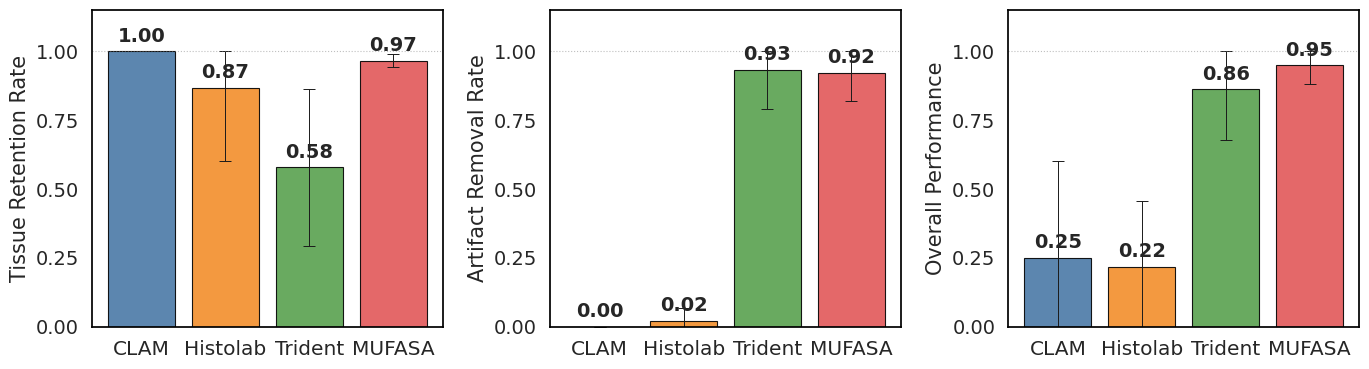

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Set plot style for publication consistency
plt.rcParams.update({
    'font.size': 17,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'axes.grid': False
})

def generate_academic_bar_charts(df, target_dataset, methods, output_dir=None):
    df_filtered = df[df['dataset'] == target_dataset].copy()
    
    if df_filtered.empty:
        print(f"No data found for dataset: {target_dataset}")
        return

    results = {'Tissue Rate': {}, 'Artifact Rate': {}, 'Performance': {}}

    for method in methods:
        # 1. Tissue Extracted Rate
        t_col = f'{method}_tissue_extracted_rate'
        if t_col in df_filtered.columns:
            t_data = df_filtered.loc[df_filtered['GT_tissue'] != 0, t_col].dropna()
            results['Tissue Rate'][method] = (t_data.mean(), t_data.std())

        # 2. Artifact Removed Rate
        a_col = f'{method}_artifact_removed_rate'
        if a_col in df_filtered.columns:
            a_data = df_filtered.loc[df_filtered['GT_artifact'] != 0, a_col].dropna()
            results['Artifact Rate'][method] = (a_data.mean(), a_data.std())

        # 3. Overall Performance
        p_col = f'{method}_performance'
        if p_col in df_filtered.columns:
            p_data = df_filtered[p_col].dropna()
            results['Performance'][method] = (p_data.mean(), p_data.std())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Updated Muted Colors (Blue, Orange, Green, Red)
    colors = ['#4A79A7', '#F28E2B', '#59A14F', '#E15759'] 

    y_labels = ['Tissue Retention Rate', 'Artifact Removal Rate', 'Overall Performance']

    for i, (metric_name, data_dict) in enumerate(results.items()):
        if not data_dict: continue
        
        names = list(data_dict.keys())
        means = np.array([data_dict[m][0] for m in names])
        stds = np.array([data_dict[m][1] for m in names])
        
        # --- Logic for Clipping Error Bars ---
        # We define asymmetric errors: [lower_errors, upper_errors]
        # Lower error is just the full SD
        lower_err = stds 
        # Upper error is clipped so Mean + UpperErr <= 1.0
        upper_err = np.minimum(stds, 1.0 - means)
        asymmetric_err = [lower_err, upper_err]

        bars = axes[i].bar(names, means, yerr=asymmetric_err, capsize=4, 
                           color=colors[:len(names)], 
                           edgecolor='black', alpha=0.9, linewidth=0.8, 
                           error_kw={'elinewidth': 0.7, 'markeredgewidth': 0.7})
        
        axes[i].set_ylabel(y_labels[i])
        axes[i].set_yticks([0, 0.25, 0.5, 0.75, 1.0]) # Cleaner ticks
        axes[i].set_ylim(0, 1.15) # Buffer for text, but data caps at 1.0
        
        # Add a light reference line at 1.0
        axes[i].axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                            f'{height:.2f}', ha='center', va='bottom', 
                             fontsize=14, fontweight='bold')

    plt.tight_layout() 

    # print(f"\n--- Statistical Results: {target_dataset} ---")
    # for metric, data in results.items():
    #     print(f"\nMetric: {metric}")
    #     for method, (mu, sigma) in data.items():
    #         print(f"  {method:10}: Mean = {mu:.4f}, SD = {sigma:.4f}")
    
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f'{target_dataset}_summary.png')
    plt.savefig(save_path, dpi=400)
    print(f"Plot saved to: {save_path}")
    
    plt.show()
    

# --- Loading your data ---
df = pd.read_csv('/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Pathologist_verification_FILLED_FINAL_NEW.csv') 
output_dir = f'/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/' 

# Mock Data Generation for Demonstration
methods = ['CLAM', 'Histolab', 'Trident', 'MUFASA'] 

# Run for BLCA
generate_academic_bar_charts(df, 'TCGA_BLCA', methods, output_dir=output_dir)

Plot saved to: /data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/TCGA_BRCA_summary.png


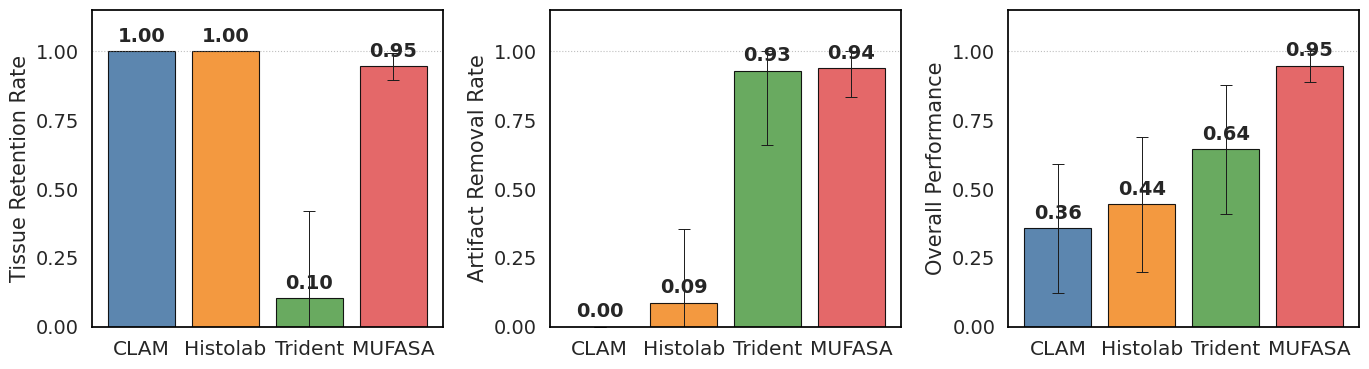

In [137]:
# Run for BLCA
generate_academic_bar_charts(df, 'TCGA_BRCA', methods, output_dir=output_dir)

Plot saved to: /data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/TCGA_COAD_summary.png


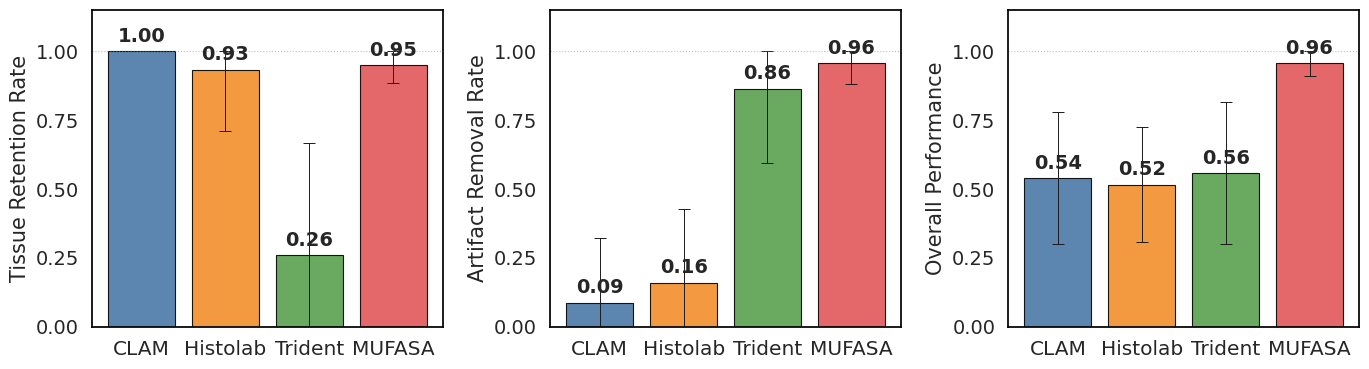

In [138]:
# Run for BLCA
generate_academic_bar_charts(df, 'TCGA_COAD', methods, output_dir=output_dir)

Plot saved to: /data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/TCGA_LUAD_summary.png


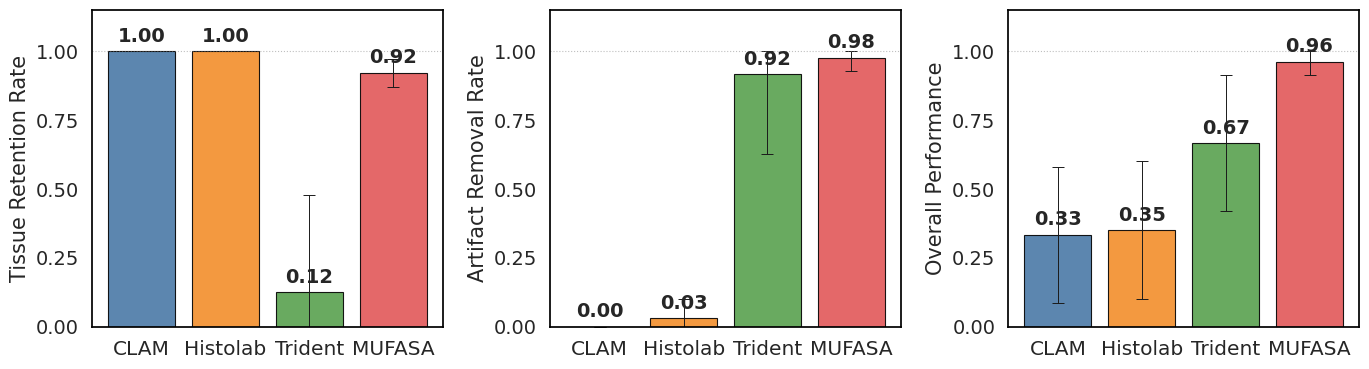

In [139]:
# Run for BLCA
generate_academic_bar_charts(df, 'TCGA_LUAD', methods, output_dir=output_dir)

Plot saved to: /data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/TCGA_READ_summary.png


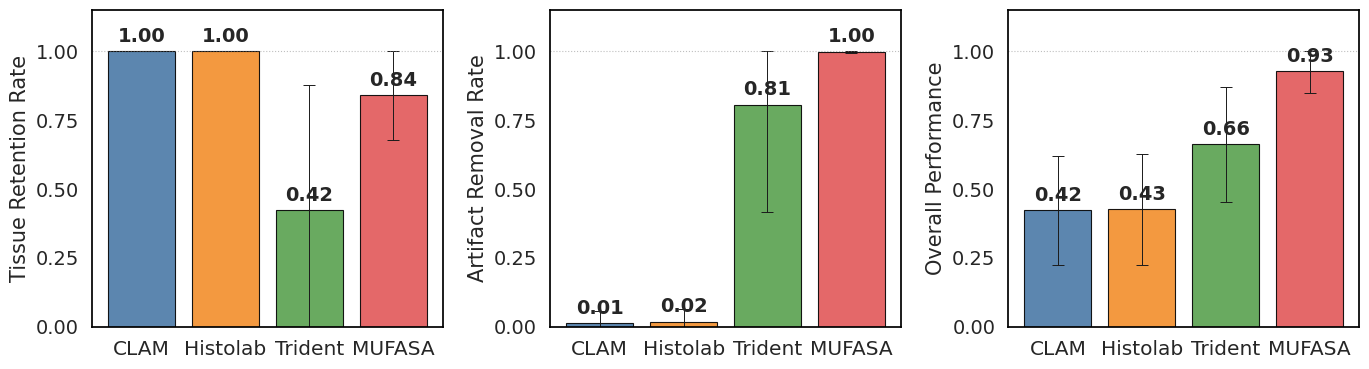

In [140]:
# Run for BLCA
generate_academic_bar_charts(df, 'TCGA_READ', methods, output_dir=output_dir)

Plot saved to: /data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/TCGA_STAD_summary.png


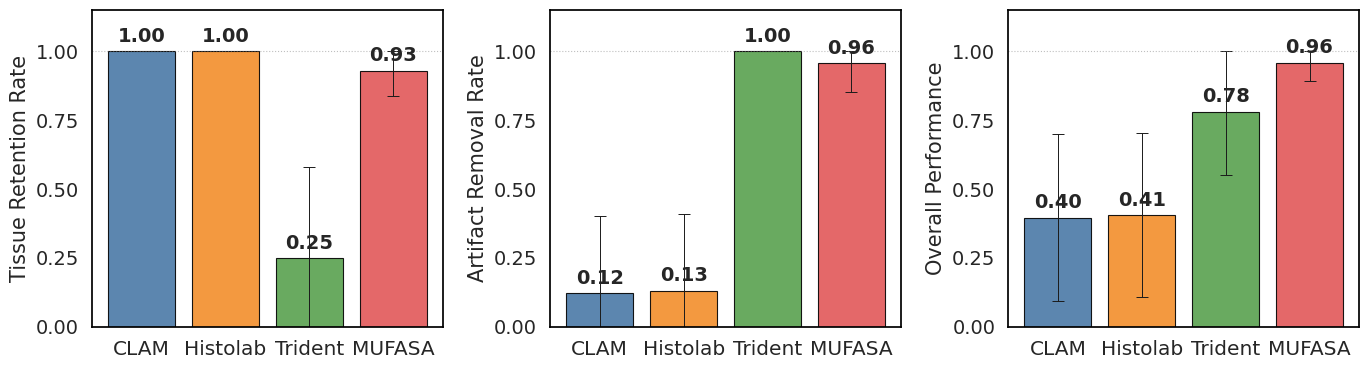

In [141]:
# Run for BLCA
generate_academic_bar_charts(df, 'TCGA_STAD', methods, output_dir=output_dir)

##### Writing the scores in a csv file

In [132]:
import pandas as pd
import numpy as np
import os

def analyze_and_export_stats(df, datasets, methods, output_dir):
    all_summaries = []

    for target_dataset in datasets:
        df_filtered = df[df['dataset'] == target_dataset].copy()
        if df_filtered.empty: continue

        for method in methods:
            # Calculate metrics using specific ground truth filters
            t_data = df_filtered.loc[df_filtered['GT_tissue'] != 0, f'{method}_tissue_extracted_rate'].dropna()
            a_data = df_filtered.loc[df_filtered['GT_artifact'] != 0, f'{method}_artifact_removed_rate'].dropna()
            p_data = df_filtered[f'{method}_performance'].dropna()

            all_summaries.append({
                'Dataset': target_dataset,
                'Method': method,
                'Tissue_Retention_Mean': t_data.mean(),
                'Tissue_Retention_SD': t_data.std(),
                'Artifact_Removal_Mean': a_data.mean(),
                'Artifact_Removal_SD': a_data.std(),
                'Overall_Performance_Mean': p_data.mean(),
                'Overall_Performance_SD': p_data.std()
            })

    # Consolidate results
    summary_df = pd.DataFrame(all_summaries)
    
    # Export to CSV
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, 'Full_Statistical_Summary.csv')
    summary_df.to_csv(csv_path, index=False)
    
    print(f"Analysis complete. Full summary saved to: {csv_path}")
    return summary_df

# --- Execution ---
input_path = '/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Pathologist_verification_FILLED_FINAL_NEW.csv'
output_dir = '/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/'

df = pd.read_csv(input_path)
methods = ['CLAM', 'Histolab', 'Trident', 'MUFASA']
datasets = ["TCGA_BLCA", "TCGA_BRCA", "TCGA_COAD", "TCGA_LUAD", "TCGA_READ", "TCGA_STAD"]

# Run the analysis
final_stats = analyze_and_export_stats(df, datasets, methods, output_dir)

Analysis complete. Full summary saved to: /data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/Full_Statistical_Summary.csv


##### Figures for stress testing and overall performance

In [133]:
import pandas as pd
import numpy as np

# Load the user's filled verification file
input_path = '/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Pathologist_verification_FILLED_FINAL_NEW.csv'
output_path = '/data_64T_3/Raja/MUFASA/Survival_analysis/ROI_patch/Plots/'

df = pd.read_csv(input_path)

# Define the methods and metrics
methods = ["CLAM", "Histolab", "Trident", "MUFASA"]
metrics = ["tissue_extracted_rate", "artifact_removed_rate", "performance"]

summary_data = []

for method in methods:
    m_dict = {"Method": method}
    for metric in metrics:
        col_name = f"{method}_{metric}"
        if col_name in df.columns:
            m_dict[f"{metric}_mean"] = df[col_name].mean()
            m_dict[f"{metric}_std"] = df[col_name].std()
    summary_data.append(m_dict)

summary_df = pd.DataFrame(summary_data)
print(summary_df)

     Method  tissue_extracted_rate_mean  tissue_extracted_rate_std  \
0      CLAM                    1.000000                   0.000000   
1  Histolab                    0.974688                   0.126934   
2   Trident                    0.263890                   0.384525   
3    MUFASA                    0.920995                   0.096642   

   artifact_removed_rate_mean  artifact_removed_rate_std  performance_mean  \
0                    0.036787                   0.152353          0.386155   
1                    0.076555                   0.201665          0.399519   
2                    0.908177                   0.259488          0.689679   
3                    0.959287                   0.082551          0.950346   

   performance_std  
0         0.268681  
1         0.250256  
2         0.239535  
3         0.059874  


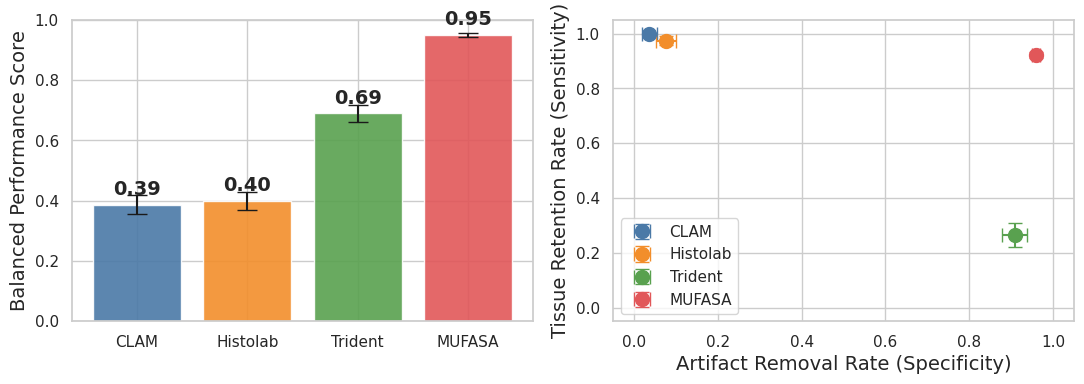

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Panel B: Grouped Bar Chart for Performance
perf_means = summary_df['performance_mean']
perf_stds = summary_df['performance_std'] / np.sqrt(len(df)) # Standard Error

bars = ax1.bar(summary_df['Method'], perf_means, yerr=perf_stds, color=[colors[m] for m in methods], capsize=7, alpha=0.9)
ax1.set_ylabel('Balanced Performance Score', fontsize=14)
# ax1.set_title('B: Overall Pre-processing Reliability', fontweight='bold', fontsize=14)
ax1.set_ylim(0, 1.0)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Panel A: Scatter Plot (The Pareto Front)
colors = {'CLAM': '#4A79A7', 'Histolab': '#F28E2B', 'Trident': '#59A14F', 'MUFASA': '#E15759'}

for method in methods:
    mean_x = summary_df.loc[summary_df['Method'] == method, 'artifact_removed_rate_mean'].values[0]
    mean_y = summary_df.loc[summary_df['Method'] == method, 'tissue_extracted_rate_mean'].values[0]
    std_x = summary_df.loc[summary_df['Method'] == method, 'artifact_removed_rate_std'].values[0]
    std_y = summary_df.loc[summary_df['Method'] == method, 'tissue_extracted_rate_std'].values[0]
    
    ax2.errorbar(mean_x, mean_y, xerr=std_x/np.sqrt(len(df)), yerr=std_y/np.sqrt(len(df)), 
                 fmt='o', color=colors[method], label=method, markersize=10, capsize=5)

ax2.set_xlabel('Artifact Removal Rate (Specificity)', fontsize=14)
ax2.set_ylabel('Tissue Retention Rate (Sensitivity)', fontsize=14)
# ax2.set_title('A: Stress-Test Quality Trade-off', fontweight='bold', fontsize=14)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.legend()

plt.tight_layout()
plt.savefig(f'{output_path}Overall_Stress_Test_Summary.png', dpi=400)
plt.show()

# Also prepare the table for display
display_table = summary_df.copy()
display_table.columns = ['Method', 'Tissue Retention (Mean)', 'Tissue Retention (SD)', 'Artifact Removal (Mean)', 'Artifact Removal (SD)', 'Balanced Performance (Mean)', 'Balanced Performance (SD)']

display_table.to_csv(f'{output_path}Overall_Stress_Test_Summary.csv', index=False)